# 06 — Feature-Level EDA
Explore the engineered feature dataset to understand class imbalance, feature distributions by depeg state, correlation structure, and temporal onset patterns. Findings here motivate the feature selection choices in `07_feature_selection.ipynb`.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| **▶ 06** | **Feature-Level EDA** | `features/pooled_5m.parquet` |
| 07 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 08 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 09 | Final Model (CatBoost) | + `selected_features.json` → `data/models/downside_depeg_catboost.cbm` + `downside_depeg_meta.json` |
| 10 | Threshold & Ops | `data/models/downside_depeg_meta.json` → threshold, alert metrics |
| 11 | LOEO Validation | `data/models/downside_depeg_meta.json` → leave-one-event-out results |

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

Running locally


In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                               # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

FEATURES_DIR = ROOT / "data" / "processed" / "features"
POOLED_PATH  = FEATURES_DIR / "pooled_5m.parquet"

COLORS = {'usdt': '#26A17B', 'usdc': '#2775CA', 'dai': '#F5AC37',
          'busd': '#F0B90B', 'ust':  '#E84142', 'usde': '#9B59B6', 'rlusd': '#00AAE4'}

print(f"Project root:  {ROOT}")
print(f"Pooled file:   {POOLED_PATH}")

Project root:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Pooled file:   /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/features/pooled_5m.parquet


## 1. Load Pooled Dataset

In [3]:
df = pd.read_parquet(POOLED_PATH)

# All label columns — cast from nullable Int8 to float
LABEL_COLS = [
    "depeg", "depeg_down",
    "depeg_next_5min",     "depeg_next_5min_down",
    "depeg_next_30min",    "depeg_next_30min_down",
    "depeg_next_1h",       "depeg_next_1h_down",
    "depeg_next_4h",       "depeg_next_4h_down",
]
for col in LABEL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(float)

print(f"Shape:               {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Coins:               {df['coin_key'].unique().tolist()}")
print(f"depeg_next_1h=1:     {int(df['depeg_next_1h'].sum()):,}  ({df['depeg_next_1h'].mean():.2%})")
print(f"depeg_next_1h_down=1:{int(df['depeg_next_1h_down'].sum()):,}  ({df['depeg_next_1h_down'].mean():.2%})")

# Stable rows only — correct scope for onset prediction
stable = df[df["depeg"] == 0].copy()
print(f"\nStable rows:         {len(stable):,}  ({len(stable)/len(df):.1%} of total)")
print(f"Onset rate (1h):     {stable['depeg_next_1h'].mean():.2%}  (stable rows only — correct modeling scope)")
print(f"Onset rate (1h_down):{stable['depeg_next_1h_down'].mean():.2%}")

Shape:               3,322,311 rows × 149 cols
Coins:               ['usdt', 'dai', 'usdc', 'busd', 'ust', 'usde', 'rlusd']
depeg_next_1h=1:     244,552  (7.36%)
depeg_next_1h_down=1:50,578  (1.52%)



Stable rows:         3,099,670  (93.3% of total)
Onset rate (1h):     0.75%  (stable rows only — correct modeling scope)
Onset rate (1h_down):0.19%


## 2. Class Imbalance
The model predicts **onset** — will a depeg begin within 1 hour? Rows where `depeg=1` are excluded from training (continuation, not onset). Two targets shown: symmetric (`depeg_next_1h`) and downside-only (`depeg_next_1h_down`).

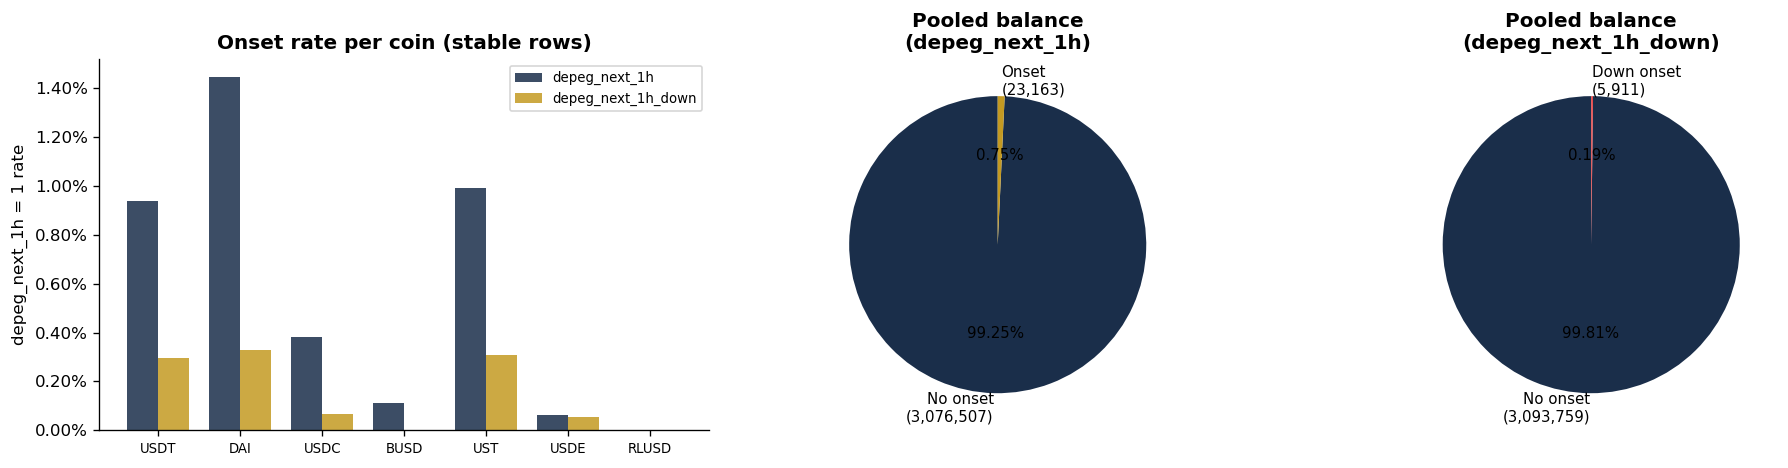

scale_pos_weight (1h):      ~133:1
scale_pos_weight (1h_down): ~523:1


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

coins = stable['coin_key'].unique()
bar_colors = [COLORS.get(c, '#888') for c in coins]
x = np.arange(len(coins))
w = 0.38

# Left: onset rates per coin — both targets side by side
onset_1h      = [stable.loc[stable['coin_key']==c, 'depeg_next_1h'].mean()      for c in coins]
onset_1h_down = [stable.loc[stable['coin_key']==c, 'depeg_next_1h_down'].mean() for c in coins]

axes[0].bar(x - w/2, onset_1h,      w, label='depeg_next_1h',      color='#1A2E4A', alpha=0.85)
axes[0].bar(x + w/2, onset_1h_down, w, label='depeg_next_1h_down', color='#C49A22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.upper() for c in coins], fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
axes[0].set_title("Onset rate per coin (stable rows)", fontweight="bold")
axes[0].set_ylabel("depeg_next_1h = 1 rate")
axes[0].legend(fontsize=8)

# Middle: pooled pie — symmetric
pos = int(stable['depeg_next_1h'].sum())
neg = len(stable) - pos
axes[1].pie([neg, pos],
            labels=[f"No onset\n({neg:,})", f"Onset\n({pos:,})"],
            colors=["#1A2E4A", "#C49A22"],
            autopct="%1.2f%%", startangle=90,
            textprops={"fontsize": 9})
axes[1].set_title("Pooled balance\n(depeg_next_1h)", fontweight="bold")

# Right: pooled pie — downside
pos_d = int(stable['depeg_next_1h_down'].sum())
neg_d = len(stable) - pos_d
axes[2].pie([neg_d, pos_d],
            labels=[f"No onset\n({neg_d:,})", f"Down onset\n({pos_d:,})"],
            colors=["#1A2E4A", "#E84142"],
            autopct="%1.2f%%", startangle=90,
            textprops={"fontsize": 9})
axes[2].set_title("Pooled balance\n(depeg_next_1h_down)", fontweight="bold")

plt.tight_layout()
plt.show()
print(f"scale_pos_weight (1h):      ~{neg/pos:.0f}:1")
print(f"scale_pos_weight (1h_down): ~{neg_d/pos_d:.0f}:1")

## 3. Feature Means — Onset vs Stable
For each feature group, compare the mean value when `depeg_next_1h=1` (onset) versus `depeg_next_1h=0` (stable). Large ratios identify the most discriminating signals.

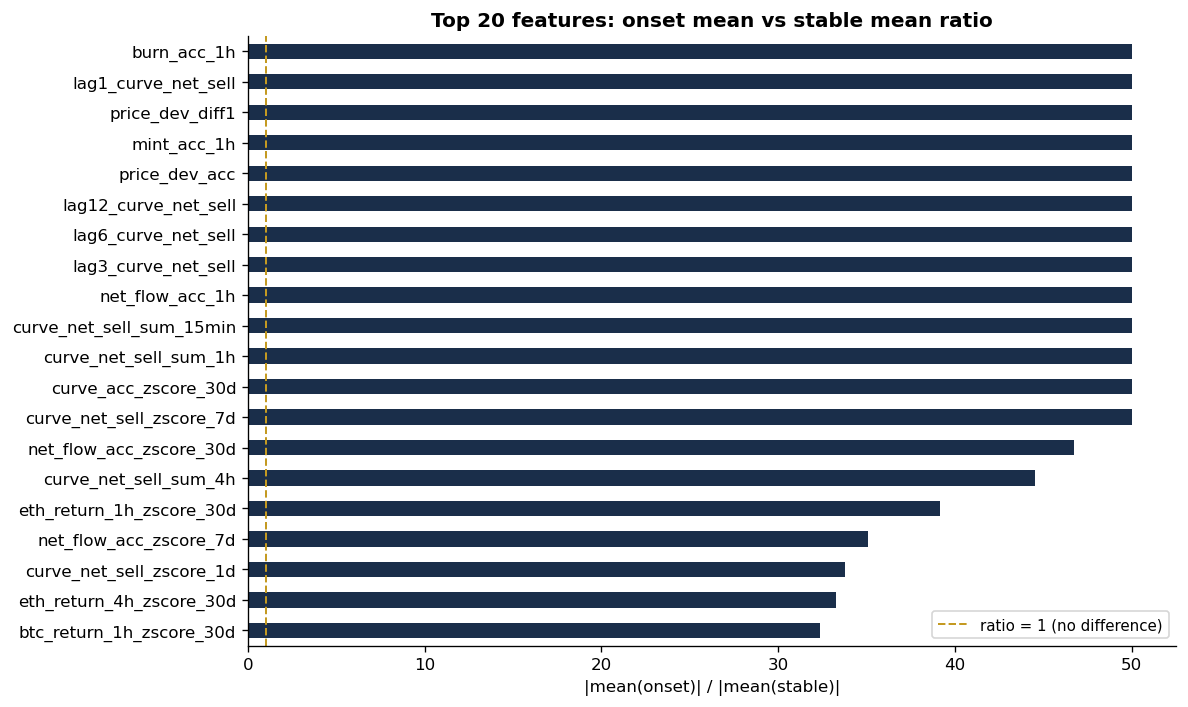


Feature columns in analysis: 126


In [5]:
META = {
    "coin_key", "date", "time", "coin", "peg", "coin_type", "coin_status",
    # All label columns — exclude from feature analysis
    "depeg", "depeg_down",
    "depeg_next_5min",     "depeg_next_5min_down",
    "depeg_next_30min",    "depeg_next_30min_down",
    "depeg_next_1h",       "depeg_next_1h_down",
    "depeg_next_4h",       "depeg_next_4h_down",
}
EXCLUDE = {"coinapi_open", "coinapi_high", "coinapi_low", "coinapi_close",
           "binance_btc_close", "binance_eth_close"}

feat_cols = [c for c in stable.columns
             if c not in META and c not in EXCLUDE
             and pd.api.types.is_numeric_dtype(stable[c])]

onset_mean  = stable.loc[stable['depeg_next_1h']==1, feat_cols].mean()
stable_mean = stable.loc[stable['depeg_next_1h']==0, feat_cols].mean()

# Ratio of means (abs, clipped) — a simple discrimination signal
ratio = (onset_mean.abs() / (stable_mean.abs() + 1e-10)).clip(upper=50)
top20 = ratio.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot.barh(ax=ax, color="#1A2E4A")
ax.axvline(1, color="#C49A22", lw=1.2, ls="--", label="ratio = 1 (no difference)")
ax.set_xlabel("|mean(onset)| / |mean(stable)|")
ax.set_title("Top 20 features: onset mean vs stable mean ratio", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nFeature columns in analysis: {len(feat_cols)}")

## 4. Correlation Heatmap — Top Features
High inter-feature correlation (|r| > 0.95) signals redundancy. The feature selection step will drop one of each highly correlated pair.

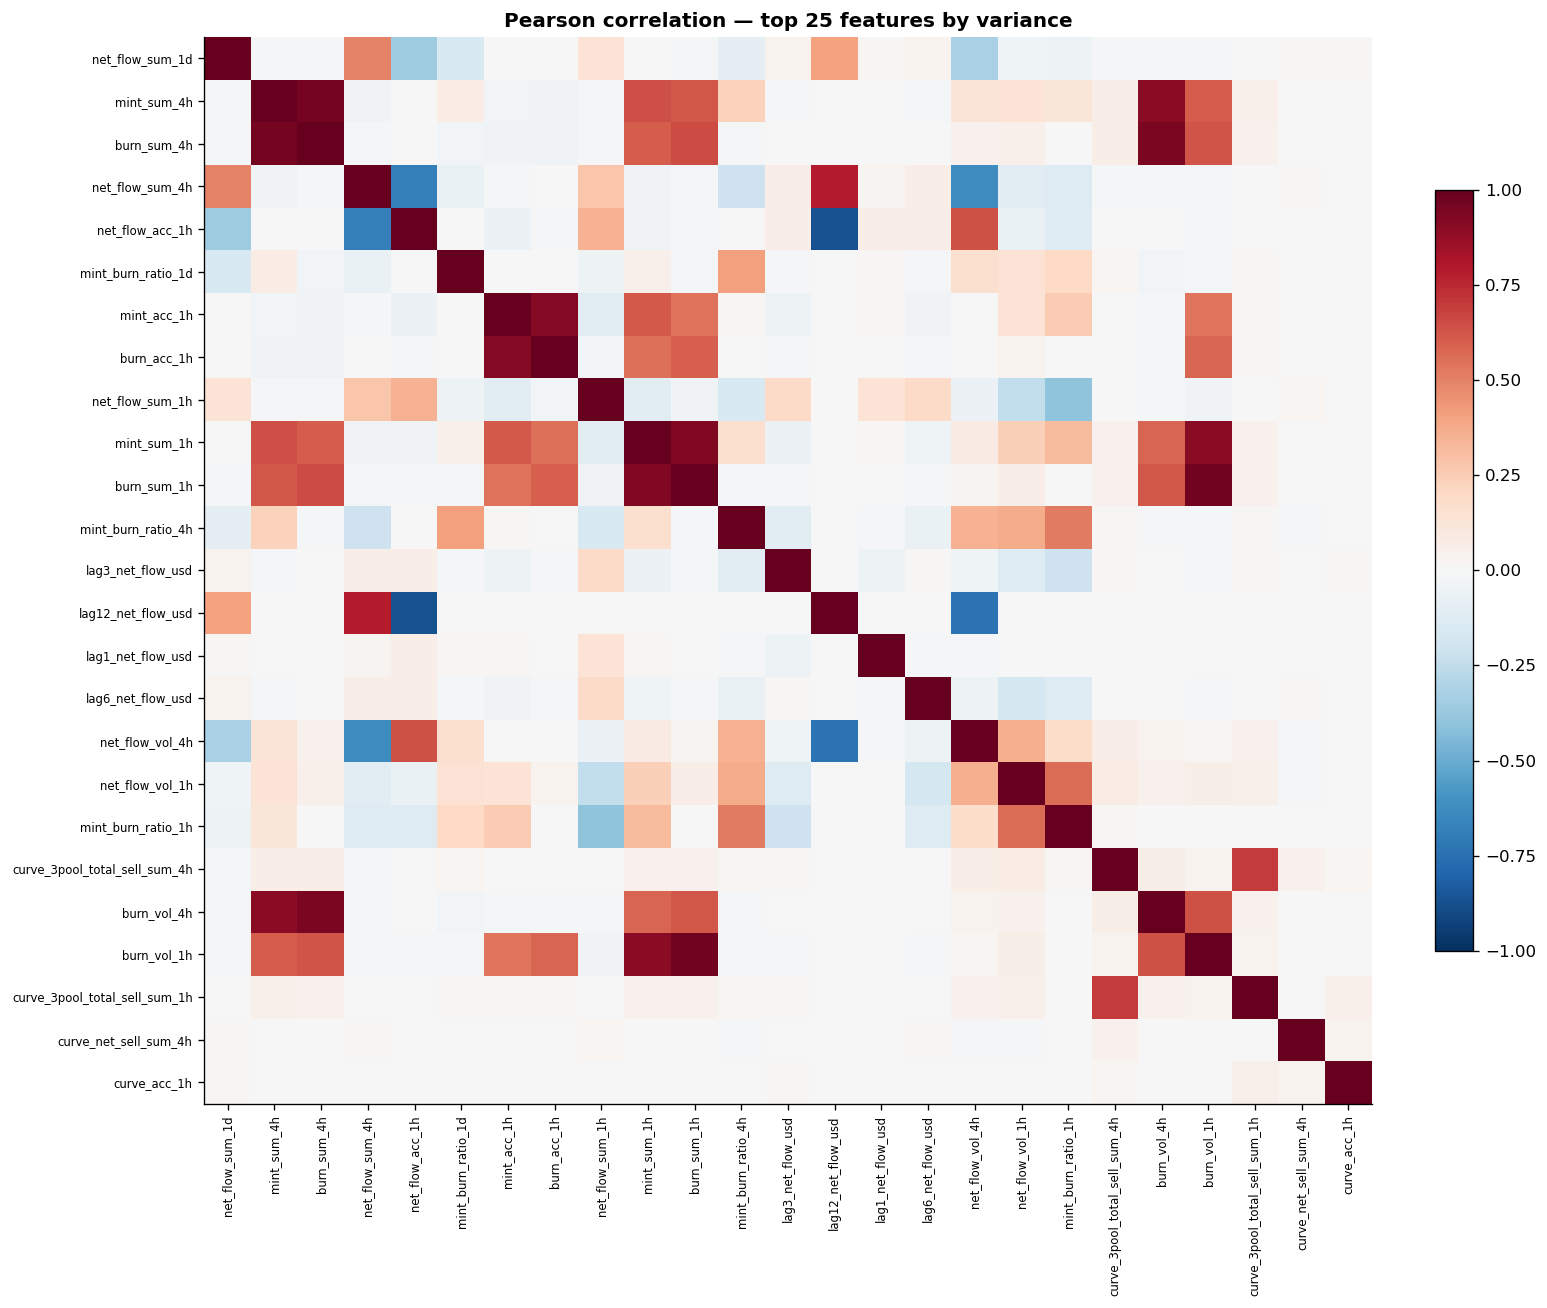

Pairs with |r| > 0.95 (in top-25 subset): 2
  burn_sum_1h                               burn_vol_1h                               r=0.967
  mint_sum_4h                               burn_sum_4h                               r=0.954


In [6]:
# Use top 25 by variance for a readable heatmap
top_var = stable[feat_cols].var().sort_values(ascending=False).head(25).index.tolist()
sample  = stable[top_var].sample(n=min(100_000, len(stable)), random_state=42)
corr    = sample.corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xticks(range(len(top_var)))
ax.set_yticks(range(len(top_var)))
ax.set_xticklabels(top_var, rotation=90, fontsize=7)
ax.set_yticklabels(top_var, fontsize=7)
ax.set_title("Pearson correlation — top 25 features by variance", fontweight="bold")
plt.tight_layout()
plt.show()

# Count highly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c1, c2, upper.loc[c1, c2])
             for c1 in upper.index for c2 in upper.columns
             if pd.notna(upper.loc[c1, c2]) and abs(upper.loc[c1, c2]) > 0.95]
print(f"Pairs with |r| > 0.95 (in top-25 subset): {len(high_corr)}")
for c1, c2, r in sorted(high_corr, key=lambda x: -abs(x[2]))[:10]:
    print(f"  {c1:<40s}  {c2:<40s}  r={r:.3f}")

## 5. Key Feature Distributions — Onset vs Stable
Box plots comparing the distribution of the top discriminating features between onset and stable rows. Log scale on x-axis where values span orders of magnitude.

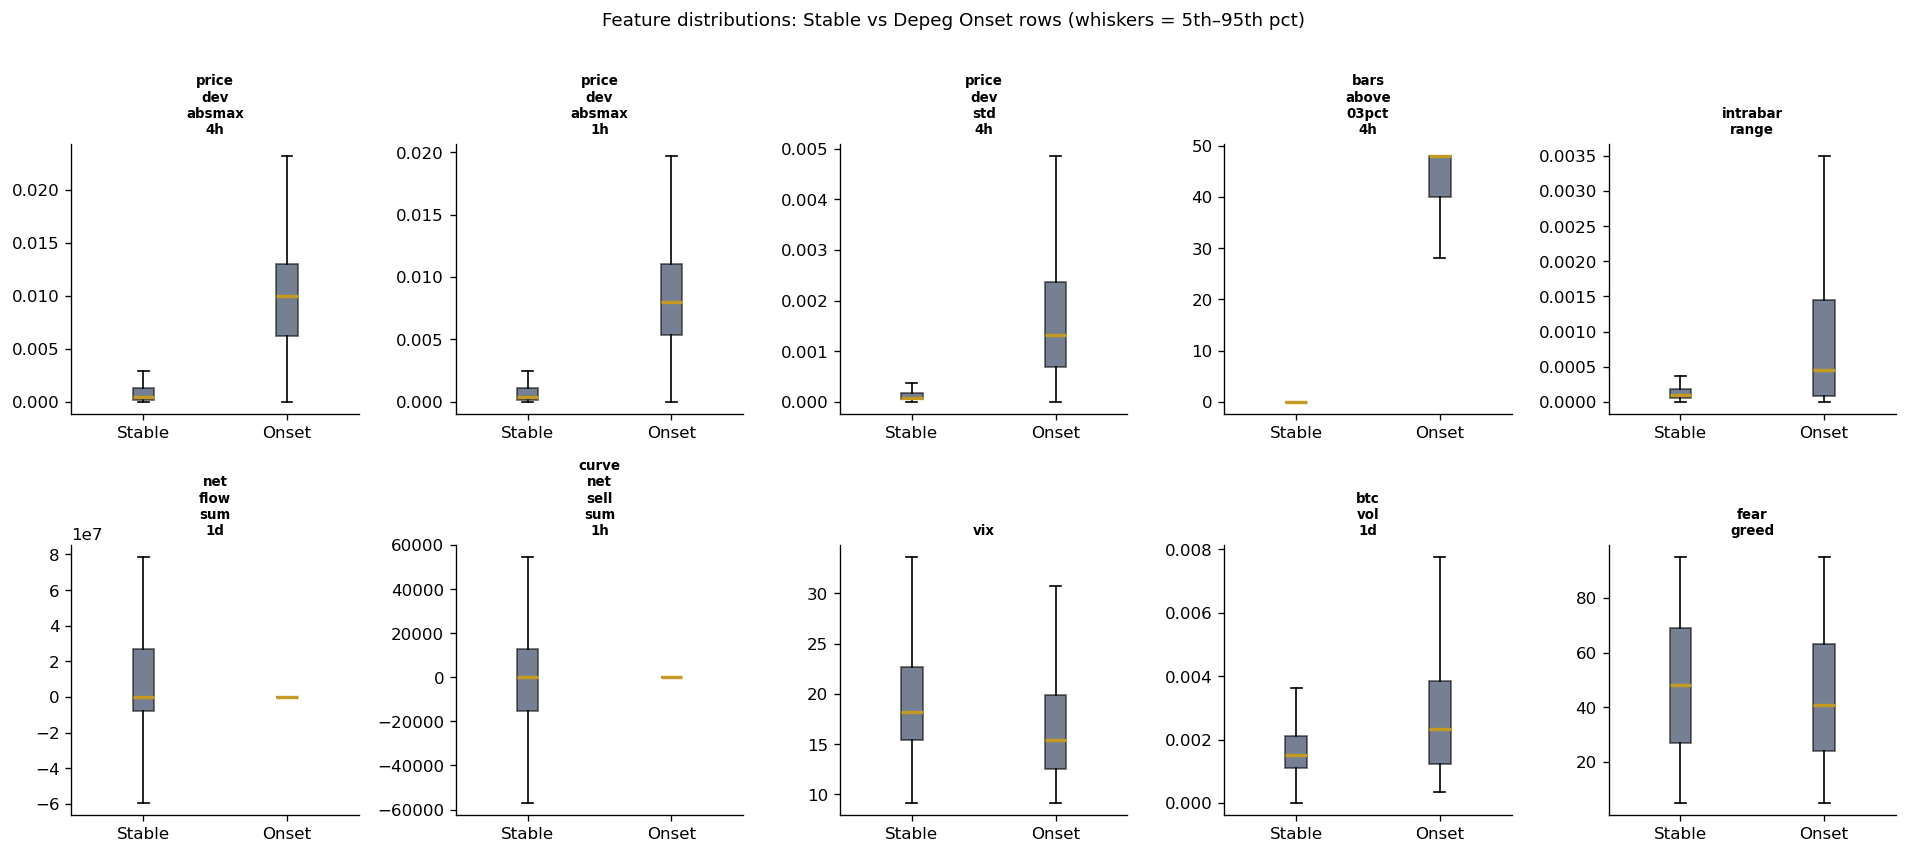

In [7]:
SHOW_FEATURES = [
    "price_dev_absmax_4h",
    "price_dev_absmax_1h",
    "price_dev_std_4h",
    "bars_above_03pct_4h",
    "intrabar_range",
    "net_flow_sum_1d",
    "curve_net_sell_sum_1h",
    "vix",
    "btc_vol_1d",
    "fear_greed",
]
SHOW_FEATURES = [f for f in SHOW_FEATURES if f in stable.columns]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

sample_stable = stable[stable['depeg_next_1h']==0].sample(n=min(50_000, (stable['depeg_next_1h']==0).sum()), random_state=42)
sample_onset  = stable[stable['depeg_next_1h']==1]

for ax, feat in zip(axes, SHOW_FEATURES):
    data_stable = sample_stable[feat].dropna()
    data_onset  = sample_onset[feat].dropna()
    ax.boxplot([data_stable, data_onset],
               labels=["Stable", "Onset"],
               patch_artist=True,
               boxprops=dict(facecolor="#1A2E4A", alpha=0.6),
               medianprops=dict(color="#C49A22", lw=2),
               showfliers=False)
    ax.set_title(feat.replace("_", "\n"), fontsize=8, fontweight="bold")

for ax in axes[len(SHOW_FEATURES):]:
    ax.set_visible(False)

fig.suptitle("Feature distributions: Stable vs Depeg Onset rows (whiskers = 5th–95th pct)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 6. Temporal Patterns — When Do Depegs Onset?
Do depegs cluster at particular times of day or days of the week? US market hours (13:30–20:00 UTC) tend to coincide with higher volatility.

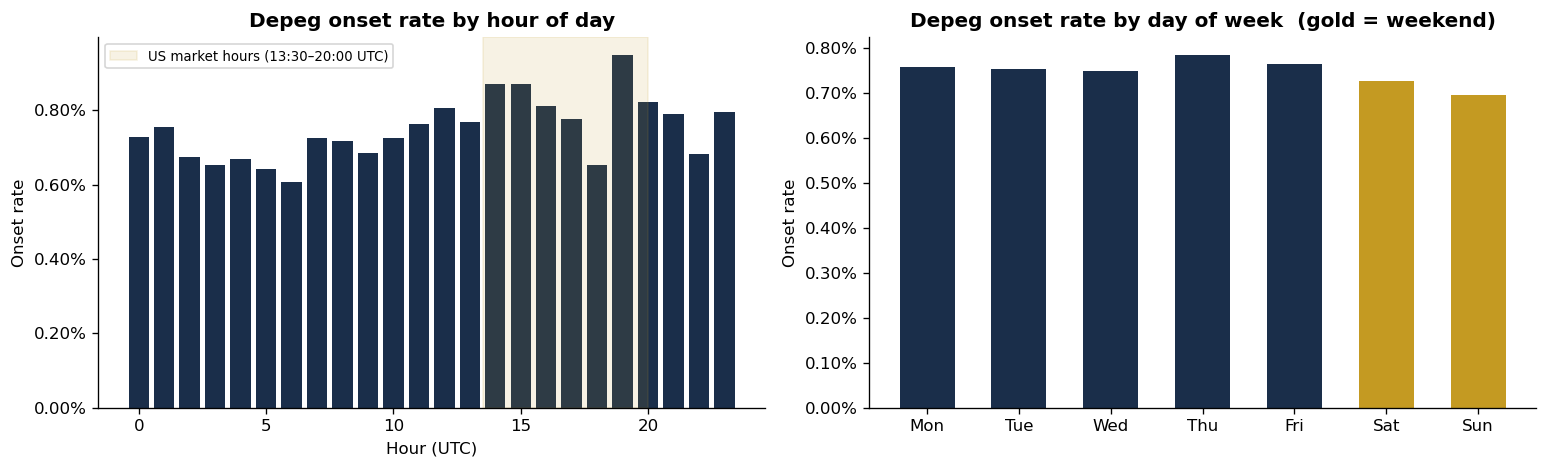

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day — onset rate
hourly = stable.groupby("hour_of_day")["depeg_next_1h"].mean()
axes[0].bar(hourly.index, hourly.values, color="#1A2E4A", width=0.8)
axes[0].axvspan(13.5, 20, alpha=0.12, color="#C49A22", label="US market hours (13:30–20:00 UTC)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2%}"))
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Onset rate")
axes[0].set_title("Depeg onset rate by hour of day", fontweight="bold")
axes[0].legend(fontsize=8)

# Day of week — onset rate
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = stable.groupby("day_of_week")["depeg_next_1h"].mean()
bar_c = ["#C49A22" if d >= 5 else "#1A2E4A" for d in daily.index]
axes[1].bar([day_labels[d] for d in daily.index], daily.values, color=bar_c, width=0.6)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2%}"))
axes[1].set_ylabel("Onset rate")
axes[1].set_title("Depeg onset rate by day of week  (gold = weekend)", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Feature Group Summary — Discriminative Power
Average onset-vs-stable ratio by feature group. This shows which groups carry the most signal before feature selection.

In [9]:
GROUPS = {
    "Price deviation":  [c for c in feat_cols if "price_dev" in c],
    "Momentum/bars":    [c for c in feat_cols if c.startswith("bars_above") or c == "intrabar_range" or c == "price_dev_diff1"],
    "On-chain flows":   [c for c in feat_cols if any(c.startswith(p) for p in ["net_flow", "mint", "burn", "total_net"])],
    "Curve DEX":        [c for c in feat_cols if c.startswith("curve_")],
    "Market returns":   [c for c in feat_cols if any(c.startswith(p) for p in ["btc_", "eth_", "vix_diff", "fear_greed_diff"])],
    "Macro (levels)":   [c for c in feat_cols if c in ["dxy", "vix", "t10y", "fedfunds", "fear_greed"]],
    "Temporal":         [c for c in feat_cols if c in ["hour_of_day", "day_of_week", "is_weekend", "is_us_market_hours"]],
    "Lags":             [c for c in feat_cols if c.startswith("lag")],
    "Cross-coin":       [c for c in feat_cols if c.startswith("cross_")],
}

grp_rows = []
for grp, cols in GROUPS.items():
    cols = [c for c in cols if c in ratio.index]
    if not cols:
        continue
    grp_rows.append({
        "Group": grp,
        "Features": len(cols),
        "Avg ratio": f"{ratio[cols].mean():.2f}×",
        "Max ratio": f"{ratio[cols].max():.2f}×",
        "Top feature": ratio[cols].idxmax(),
    })

grp_df = pd.DataFrame(grp_rows).set_index("Group").sort_values("Max ratio", ascending=False)
grp_df.style\
    .set_caption("Feature group discriminative power (onset mean / stable mean)")\
    .set_table_styles([{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}])

,Features,Avg ratio,Max ratio,Top feature
Group,,,,
Price deviation,18,15.33×,50.00×,price_dev_diff1
Momentum/bars,8,14.26×,50.00×,price_dev_diff1
On-chain flows,40,8.06×,50.00×,burn_acc_1h
Curve DEX,20,17.22×,50.00×,curve_net_sell_sum_15min
Lags,12,21.12×,50.00×,lag1_curve_net_sell
Market returns,18,9.95×,39.16×,eth_return_1h_zscore_30d
Cross-coin,2,8.53×,14.85×,cross_usdc_price_dev
Temporal,4,1.02×,1.11×,is_us_market_hours
Macro (levels),5,0.84×,0.97×,dxy


## 8. Signal Lead Time — Run-up to a Known Depeg
Plot key features in the hours before the UST collapse (May 9, 2022) to visualise how early signals appear before the price breaks.

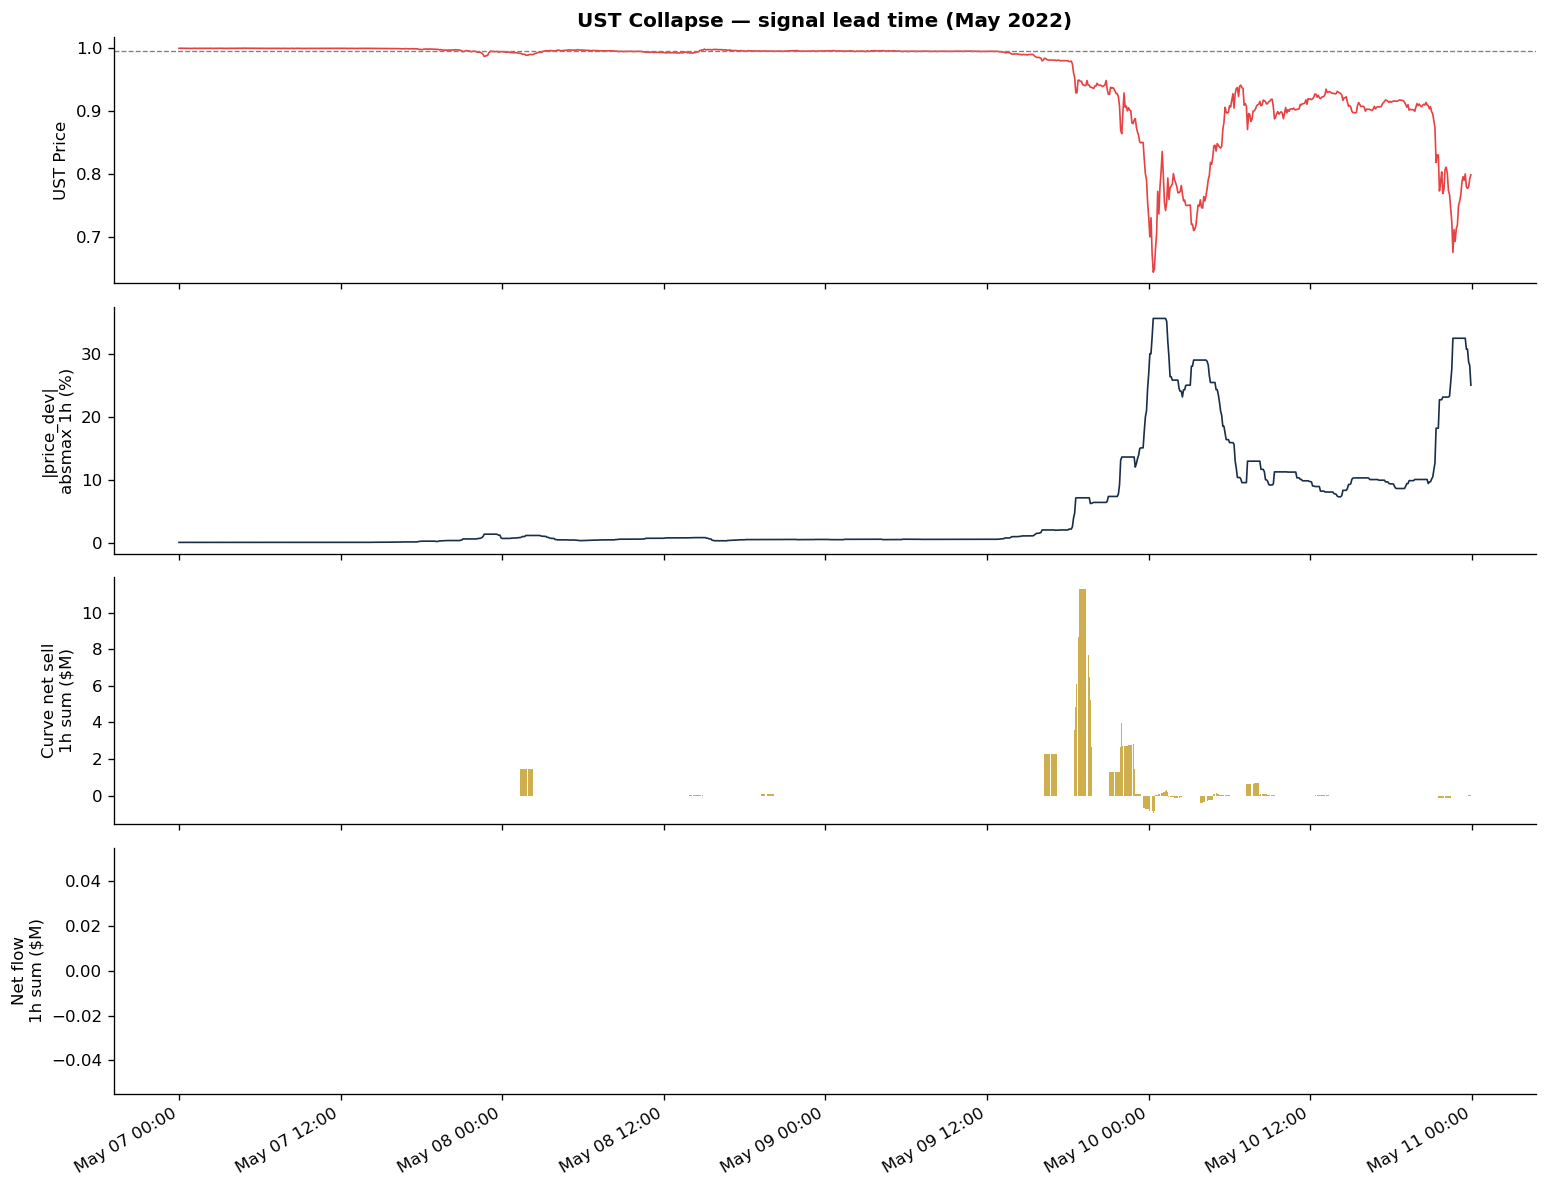

In [10]:
from pathlib import Path
ust_path = ROOT / "data" / "processed" / "features" / "ust_5m_features.parquet"

if ust_path.exists():
    ust = pd.read_parquet(ust_path)
    window = ust.loc["2022-05-07":"2022-05-10"]

    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

    # Price
    axes[0].plot(window.index, window["coinapi_close"], color="#E84142", lw=1)
    axes[0].axhline(0.995, color="gray", lw=0.8, ls="--")
    axes[0].set_ylabel("UST Price")
    axes[0].set_title("UST Collapse — signal lead time (May 2022)", fontweight="bold")

    # Price deviation rolling absmax
    if "price_dev_absmax_1h" in window.columns:
        axes[1].plot(window.index, window["price_dev_absmax_1h"] * 100, color="#1A2E4A", lw=1)
        axes[1].set_ylabel("|price_dev|\nabsmax 1h (%)")

    # Curve net sell
    if "curve_net_sell_sum_1h" in window.columns:
        axes[2].bar(window.index, window["curve_net_sell_sum_1h"] / 1e6,
                    width=0.003, color="#C49A22", alpha=0.8)
        axes[2].set_ylabel("Curve net sell\n1h sum ($M)")

    # Net flow
    if "net_flow_sum_1h" in window.columns:
        axes[3].bar(window.index, window["net_flow_sum_1h"] / 1e6,
                    width=0.003, color="#888", alpha=0.8)
        axes[3].set_ylabel("Net flow\n1h sum ($M)")

    import matplotlib.dates as mdates
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print(f"UST feature file not found at {ust_path}")
    print("Run 03_features.ipynb first to generate per-coin feature files.")

## 9. Per-Coin Feature Profiles
Mean feature values per coin on stable rows — shows how coins differ in their baseline signal levels.

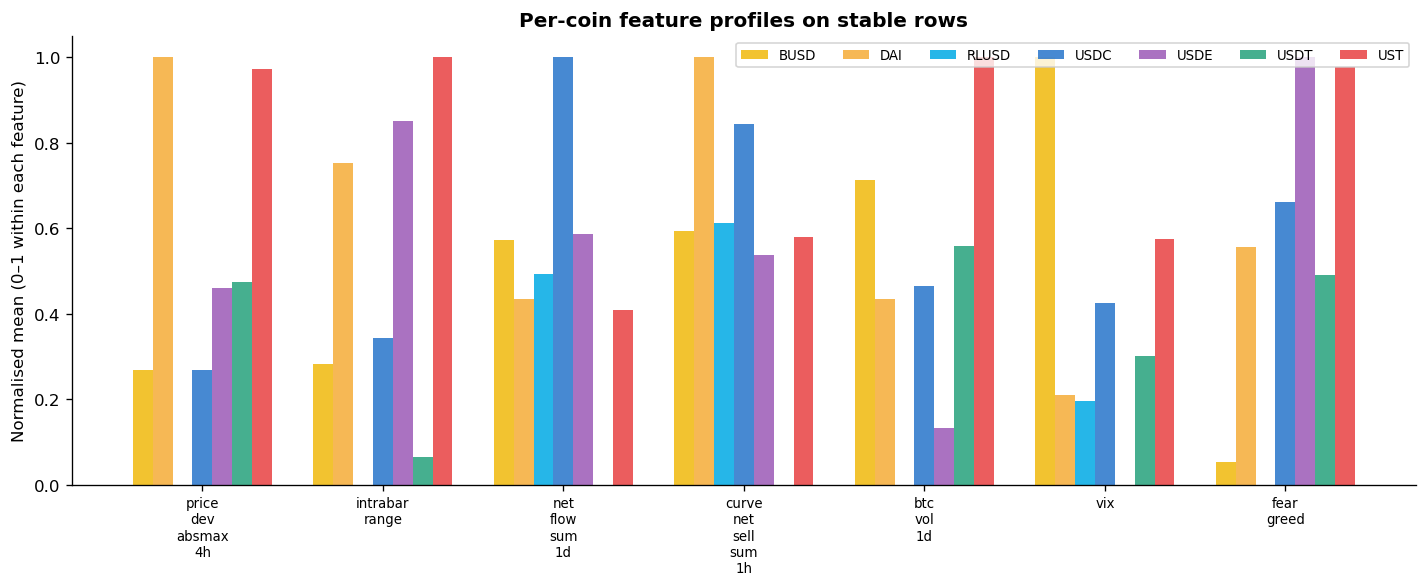

In [11]:
PROFILE_FEATURES = [
    "price_dev_absmax_4h", "intrabar_range",
    "net_flow_sum_1d", "curve_net_sell_sum_1h",
    "btc_vol_1d", "vix", "fear_greed",
]
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in stable.columns]

profile = stable.groupby("coin_key")[PROFILE_FEATURES].mean()

# Normalise each feature to [0,1] for radar-style comparison
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-10)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(PROFILE_FEATURES))
width = 0.11
for i, coin in enumerate(profile_norm.index):
    ax.bar(x + i * width, profile_norm.loc[coin], width=width,
           label=coin.upper(), color=COLORS.get(coin, "#888"), alpha=0.85)

ax.set_xticks(x + width * (len(profile_norm.index) - 1) / 2)
ax.set_xticklabels([f.replace("_", "\n") for f in PROFILE_FEATURES], fontsize=8)
ax.set_ylabel("Normalised mean (0–1 within each feature)")
ax.set_title("Per-coin feature profiles on stable rows", fontweight="bold")
ax.legend(fontsize=8, ncol=7, loc="upper right")
plt.tight_layout()
plt.show()

## 10. Next Step
Run `07_feature_selection.ipynb` to reduce 68 features to ~15 using correlation filtering + XGBoost + SHAP importance.